# Chemicals in cosmetics
---

## Introduction 
The California Safe Cosmetics Program (CSCP), managed by the California Department of Public Health (CDPH), collects information on cosmetic products sold in California that contain hazardous or potentially hazardous ingredients. The program aims to make this information publicly available, helping consumers make informed decisions and supporting efforts to improve product safety. 


## Scenario
Consumers are often unaware of the hazardous chemicals present in cosmetic products. Although California requires companies to report products containing chemicals linked to cancer or reproductive harm, reporting may be incomplete.




##### California Safe Cosmetics Program (CSCP)
This project aims to analyze the California Safe Cosmetics Program dataset to identify hazardous ingredients, determine which products and brands contain them, and uncover trends that can support informed consumer choices and regulatory decision-making.


## Objectives:
Identify cosmetic products that contain hazardous chemicals.

Determine the most frequently reported hazardous chemicals.

Analyze which companies and brands report the most hazardous ingredients.

Identify product categories with the highest number of hazardous chemicals.

Examine reporting trends over time.king.

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [2]:
import pandas as pd

In [3]:
df=pd.read_csv("chemicals-in-cosmetics1.csv")
df.head()

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1


In [4]:
df.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'DiscontinuedDate',
       'ChemicalCreatedAt', 'ChemicalUpdatedAt', 'ChemicalDateRemoved',
       'ChemicalCount'],
      dtype='str')

In [5]:
df.describe()

,CDPHId,CSFId,CompanyId,PrimaryCategoryId,SubCategoryId,CasId,ChemicalId,ChemicalCount
count,112870.000000,79187.000000,112870.000000,112870.000000,112870.000000,112870.000000,112870.000000,112870.000000
mean,19993.707203,32027.268024,445.114477,51.139470,66.985922,673.754762,32313.099442,1.281784
std,12327.400697,18774.020397,405.832049,20.558343,35.958149,148.616904,20152.245894,0.629136
min,2.000000,1.000000,4.000000,1.000000,3.000000,2.000000,0.000000,0.000000
25%,8540.250000,15530.500000,86.000000,44.000000,48.000000,656.000000,13932.250000,1.000000
50%,20522.000000,31885.000000,292.000000,44.000000,52.000000,656.000000,31789.000000,1.000000
75%,30713.000000,48175.500000,747.000000,59.000000,65.000000,656.000000,50470.750000,1.000000
max,41032.000000,64115.000000,1358.000000,111.000000,172.000000,1242.000000,67177.000000,9.000000


In [6]:
df.describe(include='object')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21328\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,ProductName,CSF,CompanyName,BrandName,PrimaryCategory,SubCategory,CasNumber,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved
count,112870,78762,112870,112647,112870,112870,106581,112870,112870,112870,12906,112870,112870,2921
unique,33267,33894,601,2682,13,89,125,123,2204,2106,986,2249,2255,514
top,Eyecolor,Black,L'Oreal USA,NYX,Makeup Products (non-permanent),"Lip Color - Lipsticks, Liners, and Pencils",13463-67-7,Titanium dioxide,10/13/2009,12/30/2010,10/02/2016,10/13/2009,10/13/2009,12/14/2009
freq,766,247,5734,3227,74524,16370,91873,92304,2557,18127,1454,2742,2645,159


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112870 entries, 0 to 112869
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   CDPHId                  112870 non-null  int64  
 1   ProductName             112870 non-null  str    
 2   CSFId                   79187 non-null   float64
 3   CSF                     78762 non-null   str    
 4   CompanyId               112870 non-null  int64  
 5   CompanyName             112870 non-null  str    
 6   BrandName               112647 non-null  str    
 7   PrimaryCategoryId       112870 non-null  int64  
 8   PrimaryCategory         112870 non-null  str    
 9   SubCategoryId           112870 non-null  int64  
 10  SubCategory             112870 non-null  str    
 11  CasId                   112870 non-null  int64  
 12  CasNumber               106581 non-null  str    
 13  ChemicalId              112870 non-null  int64  
 14  ChemicalName            112870 

In [8]:
df['InitialDateReported'].sort_index()

0         06/17/2009
1         07/01/2009
2         07/01/2009
3         07/09/2009
4         07/09/2009
             ...    
112865    02/10/2020
112866    02/10/2020
112867    02/10/2020
112868    02/10/2020
112869    02/10/2020
Name: InitialDateReported, Length: 112870, dtype: str

In [9]:
df['ChemicalCreatedAt'].sort_index()

0         07/09/2009
1         07/01/2009
2         07/02/2009
3         07/09/2009
4         07/09/2009
             ...    
112865    02/10/2020
112866    02/10/2020
112867    02/10/2020
112868    02/10/2020
112869    02/10/2020
Name: ChemicalCreatedAt, Length: 112870, dtype: str

In [10]:
df['PrimaryCategory'].value_counts()

PrimaryCategory
Makeup Products (non-permanent)      74524
Nail Products                        15102
Skin Care Products                    7613
Sun-Related Products                  4939
Bath Products                         3417
Hair Coloring Products                2053
Hair Care Products (non-coloring)     1595
Tattoos and Permanent Makeup          1477
Personal Care Products                 753
Fragrances                             644
Oral Hygiene Products                  482
Shaving Products                       222
Baby Products                           49
Name: count, dtype: int64

In [11]:
#df['PrimaryCategory'].value_counts().plot(kind='barh', grid=True);

In [12]:
#df['SubCategory'].value_counts().plot(kind='barh', grid=True)

In [13]:
#df['CompanyName'].sample(11).value_counts().plot(kind='pie')

### Data Handling: 
__Cleaning, transforming, and combining data__

In [14]:
df.drop_duplicates(inplace=True,ignore_index=True)
df

,CDPHId,ProductName,CSFId,CSF,CompanyId,CompanyName,BrandName,PrimaryCategoryId,PrimaryCategory,SubCategoryId,...,CasNumber,ChemicalId,ChemicalName,InitialDateReported,MostRecentDateReported,DiscontinuedDate,ChemicalCreatedAt,ChemicalUpdatedAt,ChemicalDateRemoved,ChemicalCount
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112611,41032,Rainforest of the Sea� foil finger paints shad...,64105.0,astro,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
112612,41032,Rainforest of the Sea� foil finger paints shad...,64106.0,Mars,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
112613,41032,Rainforest of the Sea� foil finger paints shad...,64107.0,Bimini,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
112614,41032,Rainforest of the Sea� foil finger paints shad...,64108.0,bahama mama,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1


In [15]:
df.columns

Index(['CDPHId', 'ProductName', 'CSFId', 'CSF', 'CompanyId', 'CompanyName',
       'BrandName', 'PrimaryCategoryId', 'PrimaryCategory', 'SubCategoryId',
       'SubCategory', 'CasId', 'CasNumber', 'ChemicalId', 'ChemicalName',
       'InitialDateReported', 'MostRecentDateReported', 'DiscontinuedDate',
       'ChemicalCreatedAt', 'ChemicalUpdatedAt', 'ChemicalDateRemoved',
       'ChemicalCount'],
      dtype='str')

In [16]:
dic={'CDPHId':'CDPH_Id',
     'ProductName':'Product_Name',
     'CSFId':'CSF_Id',
     'CSF':'CSF',
     'CompanyId':'Company_Id',
     'CompanyName':'Company_Name',
     'BrandName':'Brand_Name',
     'PrimaryCategoryId':'Primary_Category_Id',
     'PrimaryCategory':'Primary_Category',
     'SubCategoryId':'Sub_Category_Id',
     'SubCategory':'Sub_Category',
     'CasId':'Cas_Id',
     'CasNumber':'Cas_Number',
     'ChemicalId':'Chemical_Id',
     'ChemicalName':'Chemical_Name',
     'InitialDateReported':'Initial_Date_Reported',
     'MostRecentDateReported':'Most_Recent_Date_Reported',
     'DiscontinuedDate':'Discontinued_Date',
     'ChemicalCreatedAt':'Chemical_Created_At',
     'ChemicalUpdatedAt':'Chemical_Updated_At',
     'ChemicalDateRemoved':'Chemical_Date_Removed',
     'ChemicalCount':'Chemical_Count'}

df.rename(columns=dic, inplace=True)
df

,CDPH_Id,Product_Name,CSF_Id,CSF,Company_Id,Company_Name,Brand_Name,Primary_Category_Id,Primary_Category,Sub_Category_Id,...,Cas_Number,Chemical_Id,Chemical_Name,Initial_Date_Reported,Most_Recent_Date_Reported,Discontinued_Date,Chemical_Created_At,Chemical_Updated_At,Chemical_Date_Removed,Chemical_Count
0,2,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),53,...,13463-67-7,6,Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,65996-92-1,4,Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,3,Glover's Medicated Shampoo,NaN,NaN,338,J. Strickland & Co.,Glover's,18,Hair Care Products (non-coloring),25,...,140-67-0,5,Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,4,PRECISION GLIMMER EYE LINER-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),46,...,13463-67-7,7,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,5,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,NaN,NaN,4,New Avon LLC,AVON,44,Makeup Products (non-permanent),52,...,13463-67-7,8,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112611,41032,Rainforest of the Sea� foil finger paints shad...,64105.0,astro,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
112612,41032,Rainforest of the Sea� foil finger paints shad...,64106.0,Mars,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
112613,41032,Rainforest of the Sea� foil finger paints shad...,64107.0,Bimini,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
112614,41032,Rainforest of the Sea� foil finger paints shad...,64108.0,bahama mama,224,Tarte Cosmetics,tarte,44,Makeup Products (non-permanent),48,...,13463-67-7,67171,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1


In [17]:
df.drop(columns=['CSF','Cas_Number'],inplace=True)

In [18]:
df.drop(columns=['CDPH_Id','CSF_Id','Primary_Category_Id','Sub_Category_Id','Company_Id','Chemical_Id','Cas_Id'],inplace=True)

In [19]:
df.isnull().sum()/ len(df)

Product_Name                 0.000000
Company_Name                 0.000000
Brand_Name                   0.001980
Primary_Category             0.000000
Sub_Category                 0.000000
Chemical_Name                0.000000
Initial_Date_Reported        0.000000
Most_Recent_Date_Reported    0.000000
Discontinued_Date            0.885816
Chemical_Created_At          0.000000
Chemical_Updated_At          0.000000
Chemical_Date_Removed        0.974062
Chemical_Count               0.000000
dtype: float64

In [20]:
#df[(df['Company_Name']=='Merle Norman Cosmetics')& (df['Brand_Name'].isnull()==False)]['Brand_Name'].unique()

In [21]:
df.loc[(df['Company_Name'] == 'Merle Norman Cosmetics') & (df['Brand_Name'].isna()),'Brand_Name'] = 'Merle Norman'

In [22]:
df.loc[(df['Company_Name'] == 'Sysco Guest Supply LLC.') & (df['Brand_Name'].isna()),'Brand_Name'] = 'NONE'

In [23]:
#df[(df['Company_Name']=='Greenbrier International, Inc.')& (df['Brand_Name'].isnull()==True)&(df['Primary_Category']=='Skin Care Products ')]

In [24]:
df.loc[(df['Company_Name']=='Greenbrier International, Inc.')& (df['Brand_Name'].isnull()==True)&(df['Primary_Category']=='Makeup Products (non-permanent)'),'Brand_Name'] = 'Sassy & Chic'

In [25]:
df.loc[(df['Company_Name']=='Greenbrier International, Inc.')& (df['Brand_Name'].isnull()==True)&(df['Primary_Category']=='Hair Care Products (non-coloring)'),'Brand_Name'] = 'April Bath & Shower'

In [26]:
df.loc[(df['Company_Name']=='Greenbrier International, Inc.')& (df['Brand_Name'].isnull()==True)&(df['Primary_Category']=='Skin Care Products '),'Brand_Name'] = 'NONE'

In [27]:
df.loc[(df["Brand_Name"].isnull())&(df['Company_Name']=='Fisk Industries Inc'),'Brand_Name'] = 'Zuri Flawless'

In [28]:
df.loc[(df["Brand_Name"].isnull())&(df['Company_Name']=='Atlas Development Limited'),'Brand_Name'] = 'APRIL BATH & SHOWER'

In [29]:
df.loc[(df["Brand_Name"].isnull())&(df['Company_Name']=='Ningbo Rejoice I/E Co., Ltd.'),'Brand_Name'] = 'NONE'

In [30]:
df.loc[(df["Brand_Name"].isnull())&(df['Company_Name']=='Jiangxi Iris Chemical Co.,Ltd'),'Brand_Name'] = 'NONE'

In [31]:
df.drop_duplicates(inplace=True,ignore_index=True)

In [32]:
df.loc[(df['Chemical_Name']=='Retinol/retinyl esters, when in daily dosages in excess of 10,000 IU, or 3,000 retinol equivalents.') ,'Chemical_Name']='Retinol/retinyl esters'

In [33]:
df

,Product_Name,Company_Name,Brand_Name,Primary_Category,Sub_Category,Chemical_Name,Initial_Date_Reported,Most_Recent_Date_Reported,Discontinued_Date,Chemical_Created_At,Chemical_Updated_At,Chemical_Date_Removed,Chemical_Count
0,ULTRA COLOR RICH EXTRA PLUMP LIPSTICK-ALL SHADES,New Avon LLC,AVON,Makeup Products (non-permanent),"Lip Color - Lipsticks, Liners, and Pencils",Titanium dioxide,06/17/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
1,Glover's Medicated Shampoo,J. Strickland & Co.,Glover's,Hair Care Products (non-coloring),Hair Shampoos (making a cosmetic claim),Distillates (coal tar),07/01/2009,07/01/2009,NaN,07/01/2009,07/01/2009,NaN,2
2,Glover's Medicated Shampoo,J. Strickland & Co.,Glover's,Hair Care Products (non-coloring),Hair Shampoos (making a cosmetic claim),Estragole,07/01/2009,07/01/2009,NaN,07/02/2009,07/02/2009,NaN,2
3,PRECISION GLIMMER EYE LINER-ALL SHADES �,New Avon LLC,AVON,Makeup Products (non-permanent),Eyeliner/Eyebrow Pencils,Titanium dioxide,07/09/2009,08/28/2013,NaN,07/09/2009,07/09/2009,NaN,1
4,AVON BRILLIANT SHINE LIP GLOSS-ALL SHADES �,New Avon LLC,AVON,Makeup Products (non-permanent),Lip Gloss/Shine,Titanium dioxide,07/09/2009,08/28/2013,02/01/2011,07/09/2009,07/09/2009,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
45607,DDB leave your mark eyeshadow palette,Tarte Cosmetics,tarte,Makeup Products (non-permanent),Eye Shadow,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
45608,unleashed eyeshadow palette,Tarte Cosmetics,tarte,Makeup Products (non-permanent),Eye Shadow,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
45609,chrome paint shadow pot,Tarte Cosmetics,tarte,Makeup Products (non-permanent),Face Powders,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1
45610,tarte-LIT chrome paint highlighter,Tarte Cosmetics,tarte,Makeup Products (non-permanent),Face Powders,Titanium dioxide,02/10/2020,02/10/2020,NaN,02/10/2020,02/10/2020,NaN,1


### Analysis: 
__Answering the objectives through data analysis__



### Top 10 Product that contain hazardous chemicals (barhchart)

In [52]:
df['Product_Name'].value_counts().head(10).index

Index(['Permanent Cosmetics Color', 'Dry Skin Lotion',
       'Advanced Healing Therapeutic Skin Care', 'Coal Tar Shampoo',
       'Nail Lacquer', 'Lipstick', 'Eye Shadow', 'Deep Moisturizing Body Wash',
       'Lip Gloss', 'MATTE REVOLUTION'],
      dtype='str', name='Product_Name')

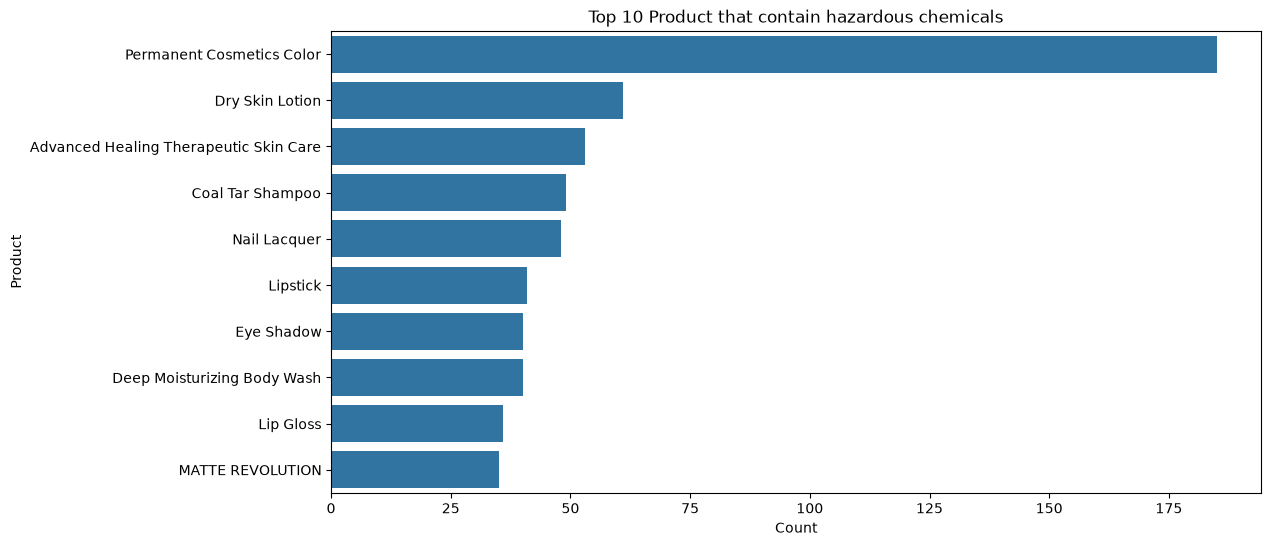

<Figure size 640x480 with 0 Axes>

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_companies = df['Product_Name'].value_counts().head(10).index

sns.countplot(
    data=df,
    y='Product_Name',
    order=top_companies
)
plt.title('Top 10 Product that contain hazardous chemicals')
plt.xlabel('Count')
plt.ylabel('Product')
plt.show()
plt.savefig('Top product.png');

### Top 10 hazardous chemicals (barh chart)

In [53]:
df['Chemical_Name'].value_counts().head(10).index

Index(['Titanium dioxide',
       'Silica, crystalline (airborne particles of respirable size)',
       'Cocamide diethanolamine', 'Retinol/retinyl esters', 'Carbon black',
       'Mica', 'Retinyl palmitate', 'Talc', 'Vitamin A palmitate',
       'Butylated hydroxyanisole'],
      dtype='str', name='Chemical_Name')

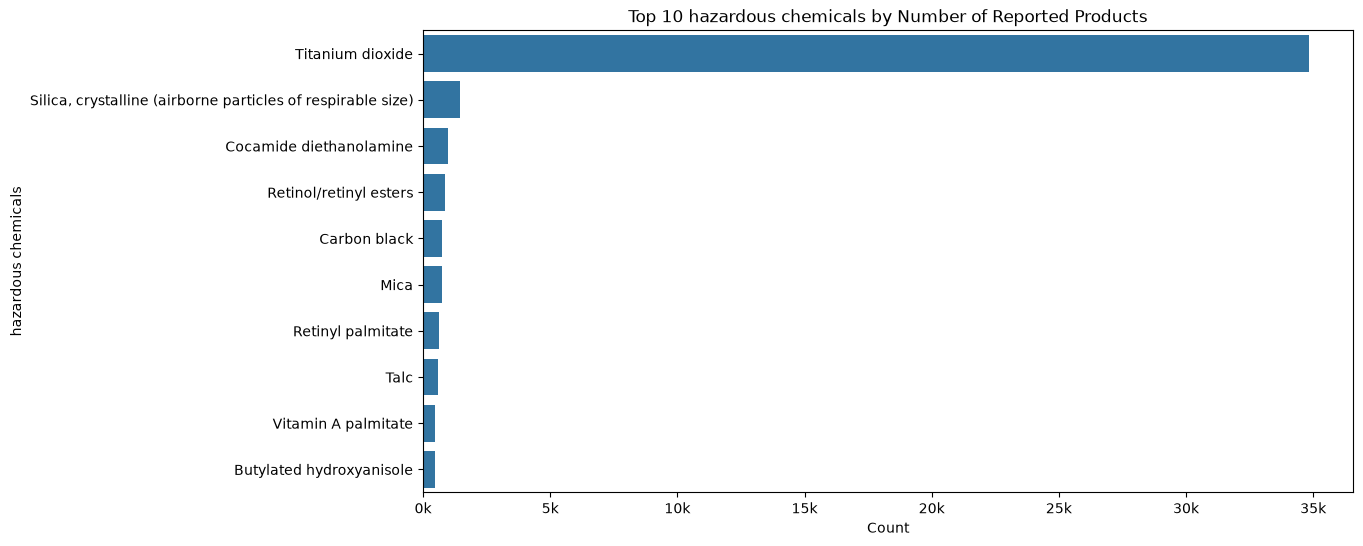

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_companies = df['Chemical_Name'].value_counts().head(10).index

sns.countplot(
    data=df,
    y='Chemical_Name',
    order=top_companies
)
plt.title('Top 10 hazardous chemicals by Number of Reported Products')
plt.xlabel('Count')
plt.ylabel('hazardous chemicals')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
plt.show()

### Top 10 companies reporting hazardous products (barh chart)

In [54]:
df['Company_Name'].value_counts().head(10).index

Index(['Nail Alliance - Entity', 'American International Industries',
       'Revlon Consumer Product Corporation', 'AMOREPACIFIC US INC.',
       'Buth-na-Bodhaige, Inc', 'S+', 'The Procter & Gamble Company', 'Coty',
       'L'Oreal USA', 'Hand & Nail Harmony, Inc'],
      dtype='str', name='Company_Name')

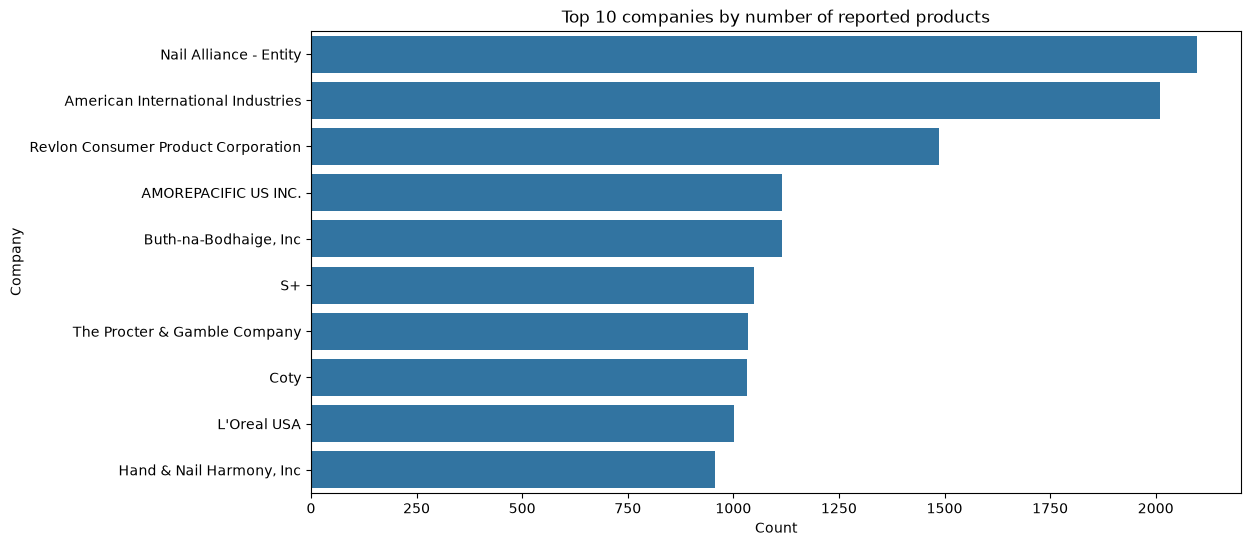

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

top_companies = df['Company_Name'].value_counts().head(10).index

sns.countplot(
    data=df,
    y='Company_Name',
    order=top_companies
)

plt.title('Top 10 companies by number of reported products')
plt.xlabel('Count')
plt.ylabel('Company')
plt.show()

### Top 10 Brand  (barh chart)

In [55]:
df['Brand_Name'].value_counts().head(10).index

Index(['The Body Shop', 'Revlon', 'Gelish', 'Entity',
       'Anastasia Beverly Hills', 'Victoria's Secret Beauty', 'ZOEVA',
       'Artistic', 'SEPHORA', 'Bath & Body Works'],
      dtype='str', name='Brand_Name')

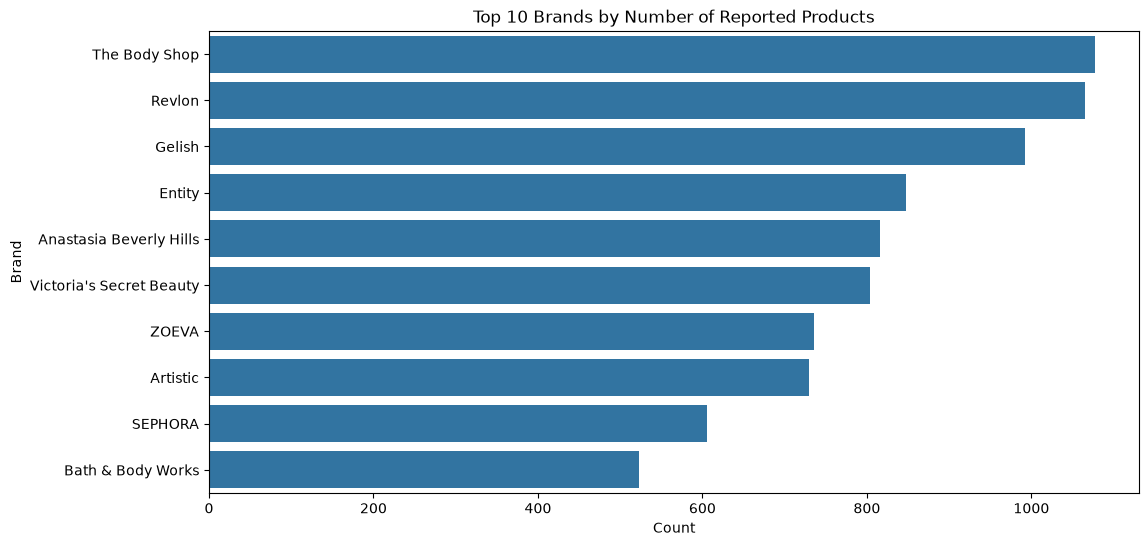

In [40]:
plt.figure(figsize=(12,6))

top_brands = df['Brand_Name'].value_counts().head(10).index

sns.countplot(
    data=df,
    y='Brand_Name',
    order=top_brands
)

plt.title('Top 10 Brands by Number of Reported Products')
plt.xlabel('Count')
plt.ylabel('Brand')
plt.show()

### Top Primary Category (barh chart)

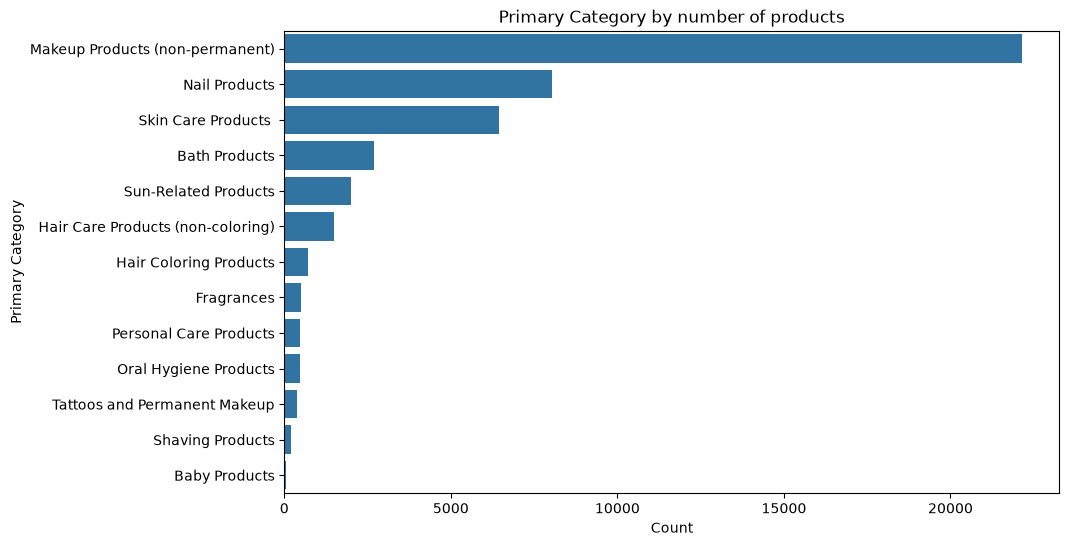

In [41]:

plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Primary_Category', order=df['Primary_Category'].value_counts().index)

plt.title('Primary Category by number of products')
plt.xlabel('Count')
plt.ylabel('Primary Category')
plt.show()

### Top Sub Category (barh chart)

In [42]:
 df['Sub_Category'].value_counts().head(10)

Sub_Category
Eye Shadow                                     4237
Nail Polish and Enamel                         3700
Foundations and Bases                          3549
Lip Color - Lipsticks, Liners, and Pencils     3536
UV Gel Nail Polish                             2822
Skin Moisturizers (making a cosmetic claim)    2673
Lip Gloss/Shine                                2554
Eyeliner/Eyebrow Pencils                       2103
Face Powders                                   1956
Sunscreen (making a cosmetic claim)            1690
Name: count, dtype: int64

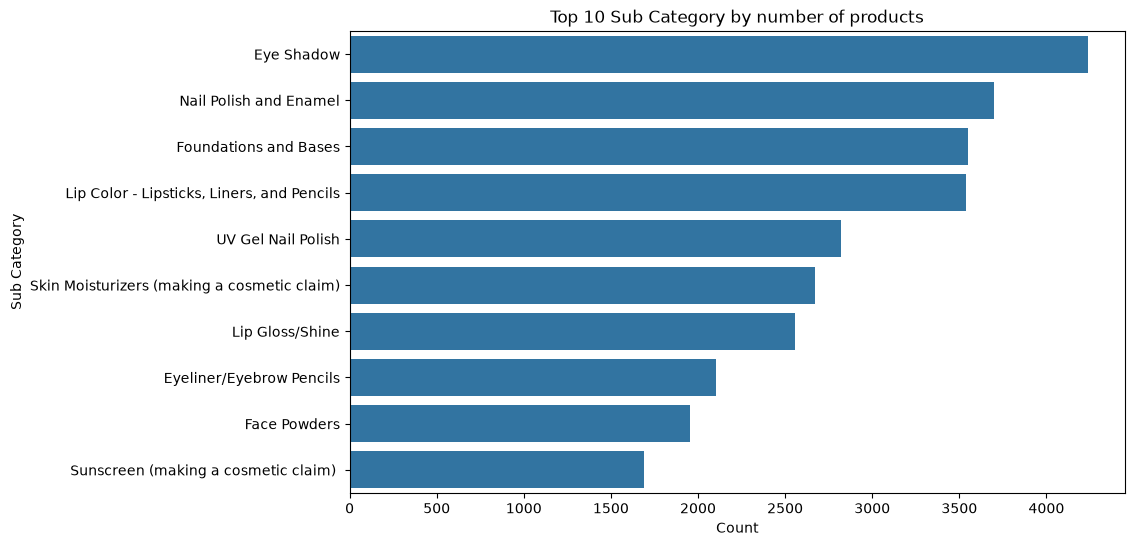

In [43]:

plt.figure(figsize=(10,6))
top_sub_category = df['Sub_Category'].value_counts().head(10).index

sns.countplot(
    data=df,
    y='Sub_Category',
    order=top_sub_category
)

plt.title('Top 10 Sub Category by number of products')
plt.xlabel('Count')
plt.ylabel('Sub Category')
plt.show()

### Reporting trend from 2009–2020 (Line chart)

In [59]:
df['Initial_Date_Reported'].dt.year.value_counts().sort_index()

Initial_Date_Reported
2009    10388
2010     6207
2011     1803
2012     1902
2013     2872
2014     3253
2015     3504
2016     2346
2017     3730
2018     3382
2019     5903
2020      322
Name: count, dtype: int64

In [61]:
df['Most_Recent_Date_Reported'].dt.year.value_counts().sort_index()

Most_Recent_Date_Reported
2009    4627
2010    5389
2011    1478
2012    1756
2013    5085
2014    3819
2015    3734
2016    3067
2017    4072
2018    4532
2019    7655
2020     398
Name: count, dtype: int64

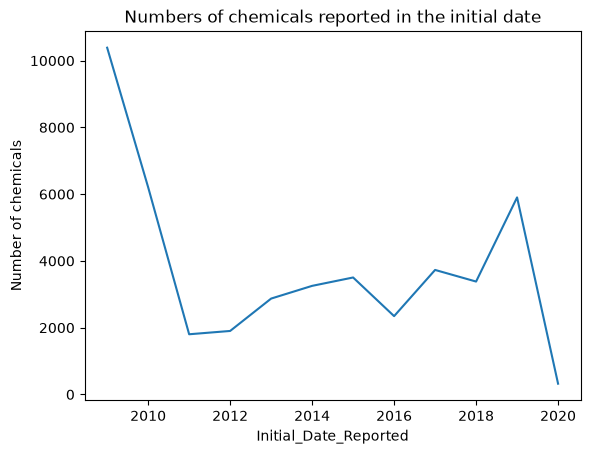

In [44]:
df['Initial_Date_Reported'] = pd.to_datetime(df['Initial_Date_Reported'])
df['Initial_Date_Reported'].dt.year.value_counts().sort_index().plot()
plt.ylabel('Number of chemicals')
plt.title('Numbers of chemicals reported in the initial date');


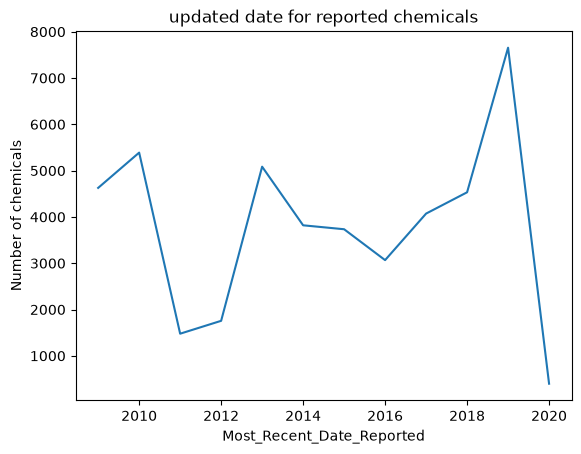

In [45]:
# chemical update (updated date for reported chemicals )
df['Most_Recent_Date_Reported'] = pd.to_datetime(df['Most_Recent_Date_Reported'])
df['Most_Recent_Date_Reported'].dt.year.value_counts().sort_index().plot()
plt.ylabel('Number of chemicals')
plt.title('updated date for reported chemicals');

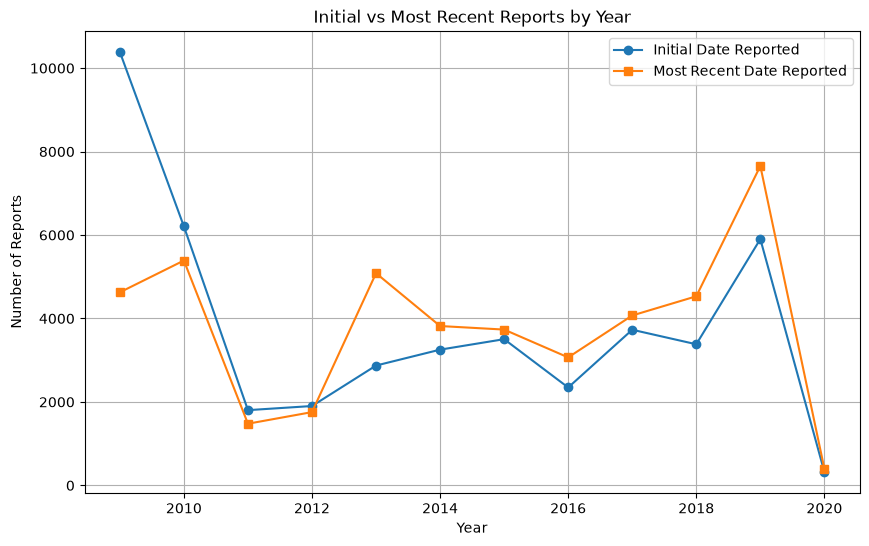

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert to datetime
df['Initial_Date_Reported'] = pd.to_datetime(df['Initial_Date_Reported'])
df['Most_Recent_Date_Reported'] = pd.to_datetime(df['Most_Recent_Date_Reported'])

# Count reports by year
initial = df['Initial_Date_Reported'].dt.year.value_counts().sort_index()
recent = df['Most_Recent_Date_Reported'].dt.year.value_counts().sort_index()

# Combine into one DataFrame
trend = pd.DataFrame({
    'Initial Reported': initial,
    'Most Recent Reported': recent
}).fillna(0)

# Plot
plt.figure(figsize=(10,6))
plt.plot(trend.index, trend['Initial Reported'], marker='o', label='Initial Date Reported')
plt.plot(trend.index, trend['Most Recent Reported'], marker='s', label='Most Recent Date Reported')

plt.title('Initial vs Most Recent Reports by Year')
plt.xlabel('Year')
plt.ylabel('Number of Reports')
plt.legend()
plt.grid(True)
plt.show()

### primary and sub catgory pie chart

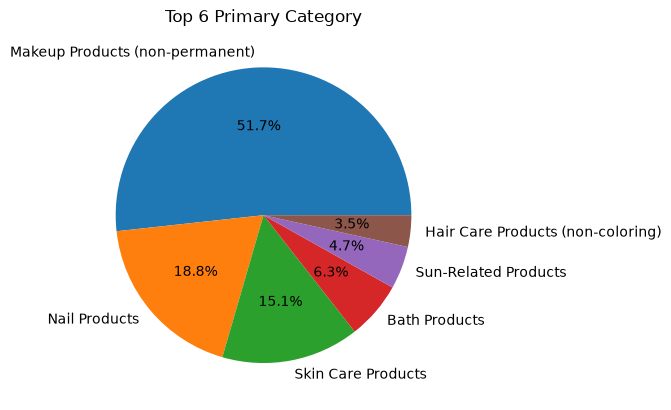

In [47]:
df['Primary_Category'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 6 Primary Category');

In [57]:
df['Sub_Category'].value_counts().head(6).index

Index(['Eye Shadow', 'Nail Polish and Enamel', 'Foundations and Bases',
       'Lip Color - Lipsticks, Liners, and Pencils', 'UV Gel Nail Polish',
       'Skin Moisturizers (making a cosmetic claim)'],
      dtype='str', name='Sub_Category')

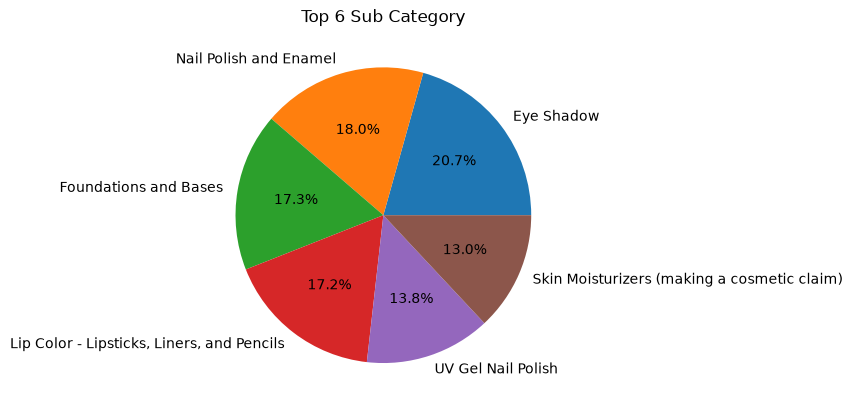

In [48]:
df['Sub_Category'].value_counts().head(6).plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 6 Sub Category');

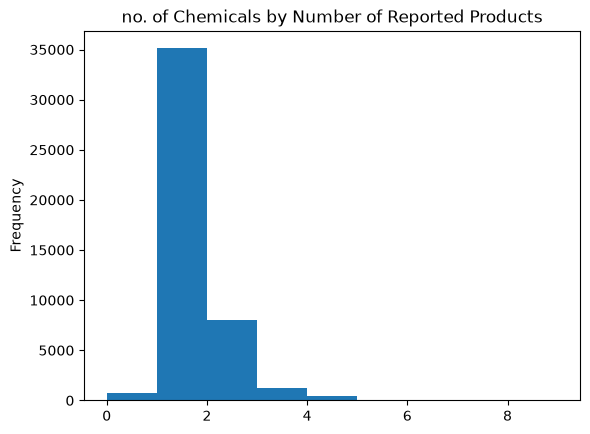

In [49]:
df['Chemical_Count'].plot(kind='hist', bins=9)
plt.title('no. of Chemicals by Number of Reported Products');

In [50]:
df['Chemical_Name'].unique()

<ArrowStringArray>
[                                 'Titanium dioxide',
                            'Distillates (coal tar)',
                                         'Estragole',
                           'Cocamide diethanolamine',
                                           'Toluene',
                   'Chromium (hexavalent compounds)',
                                           'Retinol',
                            'Retinol/retinyl esters',
                                         'Vitamin A',
                               'Vitamin A palmitate',
 ...
                           'N-Nitrosodiethanolamine',
                                    'Benzophenone-2',
                                     'Vinyl acetate',
                              'Trichloroacetic acid',
                                       'Phenacemide',
     'Aloe vera, non-decolorized whole leaf extract',
                                        'Polygeenan',
 'Diethanolamides of the fatty acids of coconut oil',
    

In [51]:
s=pd.Series(df['Chemical_Name'].unique())
s

0                                       Titanium dioxide
1                                 Distillates (coal tar)
2                                              Estragole
3                                Cocamide diethanolamine
4                                                Toluene
                             ...                        
118        Aloe vera, non-decolorized whole leaf extract
119                                           Polygeenan
120    Diethanolamides of the fatty acids of coconut oil
121                                    Bisphenol A (BPA)
122                           Hydrous magnesium silicate
Length: 123, dtype: str

In [58]:
df.describe(include='object')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21328\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Product_Name,Company_Name,Brand_Name,Primary_Category,Sub_Category,Chemical_Name,Discontinued_Date,Chemical_Created_At,Chemical_Updated_At,Chemical_Date_Removed
count,45612,45612,45612,45612,45612,45612,5927,45612,45612,1600
unique,33267,601,2682,13,89,123,986,2249,2255,514
top,Permanent Cosmetics Color,Nail Alliance - Entity,The Body Shop,Makeup Products (non-permanent),Eye Shadow,Titanium dioxide,10/02/2016,10/15/2009,10/15/2009,12/14/2009
freq,185,2097,1077,22159,4237,34827,307,855,699,109


---

## Summary

Top 10 Product that contain hazardous chemicals respectively: Permanent Cosmetics Color, Dry Skin Lotion, Advanced Healing Therapeutic Skin Care, Coal Tar Shampoo, Nail Lacquer, Lipstick, Eye Shadow, Deep Moisturizing Body Wash, Lip Gloss, MATTE  REVOLUTION.

Top 10 hazardous chemicals respectively: Titanium dioxide, (Silica, crystalline (airborne particles of respirable size)), Cocamide diethanolamine, Retinol/retinyl esters, Carbon black, Mica, Retinyl palmitate, Talc, Vitamin A palmitate, Butylated hydroxyanisole.

Top 10 companies reporting hazardous products respectively: Nail Alliance - Entity, American International Industries, Revlon Consumer Product Corporation, AMOREPACIFIC US INC., ( Buth-na-Bodhaige, Inc ) , S+, The Procter & Gamble Company, Coty, L'Oreal USA, Hand & Nail Harmony, Inc.

Top 10 Brands report the hazardous ingredients respectively: The Body Shop, Revlon, Gelish, Entity, Anastasia Beverly Hills, Victoria's Secret Beauty, ZOEVA, Artistic, SEPHORA, Bath & Body Works.

Top 6 Primary Category respectively: Makeup Products (non-permanent), Nail Products, Skin Care Products, Bath Products, Sun-Related Products, Hair Care Products (non-coloring).

Top 6 Sub Category respectively: Eye Shadow, Nail Polish and Enamel, Foundations and Bases, (Lip Color - Lipsticks, Liners, and Pencils), UV Gel Nail Polish, Skin Moisturizers (making a cosmetic claim).

According to the line chart the max of reporting hazardous ingredients in the initial Date graph is in 2009 and for the Most_Recent_Date is in 2019.
    

## Recommendations/Conclusion

Conclusion:

The analysis revealed that Titanium dioxide is the most frequently reported chemical in cosmetic products.

makeup products account for the largest product Primary category and for Sub Category is Eye Shadow . 

Companies such as  Nail Alliance - Entity, American International Industries, L'Oréal USA and Coty appear most frequently in the dataset. 

The max of reporting hazardous ingredients in the initial Date graph is in 2009 and for the Most_Recent_Date is in 2019.

----------------------------------------------------------------------------------

Recommendations:

Customers should examine product ingredients and select cosmetics that contain few or no hazardous chemicals.

Manufacturers should replace harmful ingredients with safer alternatives in their products.

Project bodies should encourage full and accurate reporting of cosmetic products.

Companies should clearly disclose ingredient information on product labels.